# Exercício SARIMA — Comércio Varejista Ampliado
## PMC/IBGE · Rio Grande do Sul · Jan/2004 em diante

**Base:** Índice de volume de vendas no comércio varejista ampliado (inclui veículos e materiais de construção), por UF, mensal. Base 2022 = 100, **sem ajuste sazonal**.

**Objetivo:** Aplicar pipeline completo de séries temporais:
análise descritiva → testes de estacionaridade → modelagem SARIMA → diagnóstico de resíduos → previsão de 24 meses.

---
## 1. Importação de Bibliotecas

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA

import pmdarima as pm
from pmdarima.arima.utils import ndiffs, nsdiffs

warnings.filterwarnings('ignore')

# Estilo visual consistente
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11
})

print('Bibliotecas carregadas com sucesso.')

C:\Users\lucas\Downloads\Exercicio SARIMA\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\lucas\Downloads\Exercicio SARIMA\.venv\Lib\site-packages\statsforecast\models.py:3811: SyntaxWarning: invalid escape sequence '\h'
  $$\hat{y}_t = \\frac{\hat{z}_t}{\hat{p}_t}$$
C:\Users\lucas\Downloads\Exercicio SARIMA\.venv\Lib\site-packages\statsforecast\models.py:3989: SyntaxWarning: invalid escape sequence '\h'
  $$\hat{y}_t = \\frac{\hat{z}_t}{\hat{p}_t}$$
C:\Users\lucas\Downloads\Exercicio SARIMA\.venv\Lib\site-packages\statsforecast\models.py:4137: SyntaxWarning: invalid escape sequence '\h'
  $$\hat{y}_t = \\frac{\hat{z}_t}{\hat{p}_t}$$
C:\Users\lucas\Downloads\Exercicio SARIMA\.venv\Lib\site-packages\statsforecast\models.py:4477: SyntaxWarning: invalid escape sequence '\e'
  \end{cases}


Bibliotecas carregadas com sucesso.


---
## 2. Carregamento e Preparação dos Dados

In [2]:
# ── Parâmetro principal ──────────────────────────────────────────────────────
MINHA_UF = "Rio Grande do Sul"
# ────────────────────────────────────────────────────────────────────────────

# Leitura da base PMC
pmc = pd.read_csv(
    "https://github.com/padsInsper/202632-fa/releases/download/data/pmc_volume_uf.csv"
)

print("Shape da base completa:", pmc.shape)
print("Colunas:", pmc.columns.tolist())
print("\nUFs disponíveis:")
print(sorted(pmc['uf'].unique()))

Shape da base completa: (7182, 3)
Colunas: ['uf', 'data', 'volume_idx']

UFs disponíveis:
['Acre', 'Alagoas', 'Amapá', 'Amazonas', 'Bahia', 'Ceará', 'Distrito Federal', 'Espírito Santo', 'Goiás', 'Maranhão', 'Mato Grosso', 'Mato Grosso do Sul', 'Minas Gerais', 'Paraná', 'Paraíba', 'Pará', 'Pernambuco', 'Piauí', 'Rio Grande do Norte', 'Rio Grande do Sul', 'Rio de Janeiro', 'Rondônia', 'Roraima', 'Santa Catarina', 'Sergipe', 'São Paulo', 'Tocantins']


In [3]:
# Filtro e formatação para a UF de interesse
df = (
    pmc
    .query("uf == @MINHA_UF")
    .assign(data=lambda x: pd.to_datetime(x['data']))
    .sort_values('data')
    .reset_index(drop=True)
)

# Formato StatsForecast (exigido pela biblioteca)
df_sf = df.rename(columns={
    'uf': 'unique_id',
    'data': 'ds',
    'volume_idx': 'y'
})[['unique_id', 'ds', 'y']]

# Série como pandas Series com índice temporal (útil para statsmodels)
serie = df.set_index('data')['volume_idx']
serie.index.freq = 'MS'  # Monthly Start

print(f"\nUF selecionada: {MINHA_UF}")
print(f"Período: {serie.index.min().strftime('%b/%Y')} → {serie.index.max().strftime('%b/%Y')}")
print(f"Observações: {len(serie)}")
print(f"\nEstatísticas descritivas:")
print(serie.describe().round(2))


UF selecionada: Rio Grande do Sul
Período: Jan/2004 → Feb/2026
Observações: 266

Estatísticas descritivas:
count    266.00
mean      86.62
std       18.72
min       46.91
25%       73.47
50%       88.62
75%       99.44
max      130.16
Name: volume_idx, dtype: float64


---
## 3. Análise Descritiva

### 3.1 Gráfico de Linha — Série Original

O primeiro passo é **ver a série**. Buscamos identificar visualmente:
- **Tendência**: a série sobe, desce ou fica estável ao longo do tempo?
- **Sazonalidade**: há padrões que se repetem a cada 12 meses?
- **Quebras estruturais**: choques pontuais (ex: pandemia 2020, enchentes RS 2024)?
- **Heterocedasticidade**: a volatilidade aumenta com o nível da série?

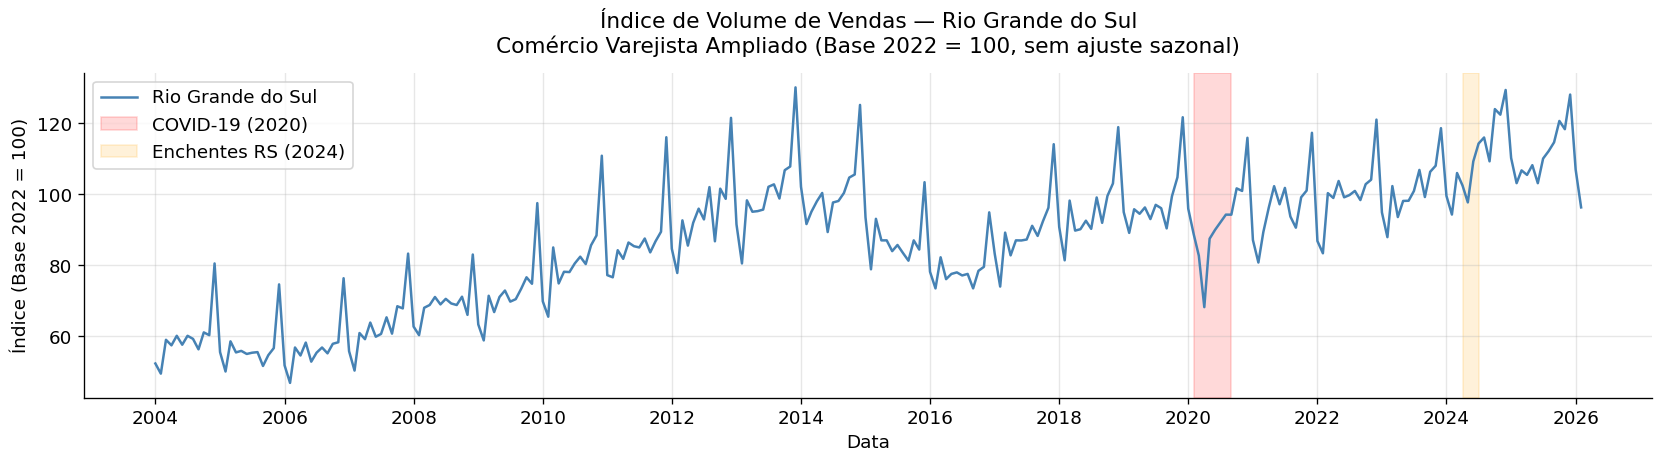

In [4]:
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(serie.index, serie.values, color='steelblue', linewidth=1.5, label=MINHA_UF)

# Destaque visual: pandemia e enchentes
ax.axvspan(pd.Timestamp('2020-02-01'), pd.Timestamp('2020-09-01'),
           alpha=0.15, color='red', label='COVID-19 (2020)')
ax.axvspan(pd.Timestamp('2024-04-01'), pd.Timestamp('2024-07-01'),
           alpha=0.15, color='orange', label='Enchentes RS (2024)')

ax.set_title(f'Índice de Volume de Vendas — {MINHA_UF}\nComércio Varejista Ampliado (Base 2022 = 100, sem ajuste sazonal)',
             fontsize=13, pad=12)
ax.set_xlabel('Data')
ax.set_ylabel('Índice (Base 2022 = 100)')
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

### 3.2 ACF e PACF — Série Original

**ACF (Autocorrelação):** mede a correlação da série com ela mesma em diferentes defasagens.  
**PACF (Autocorrelação Parcial):** mede a correlação direta em cada lag, removendo o efeito dos lags intermediários.

**O que buscar:**
- Decaimento lento no ACF → tendência (série não estacionária)
- Spikes fortes nos lags 12, 24, 36 → sazonalidade anual
- Corte abrupto no PACF após lag *p* → componente AR(*p*)

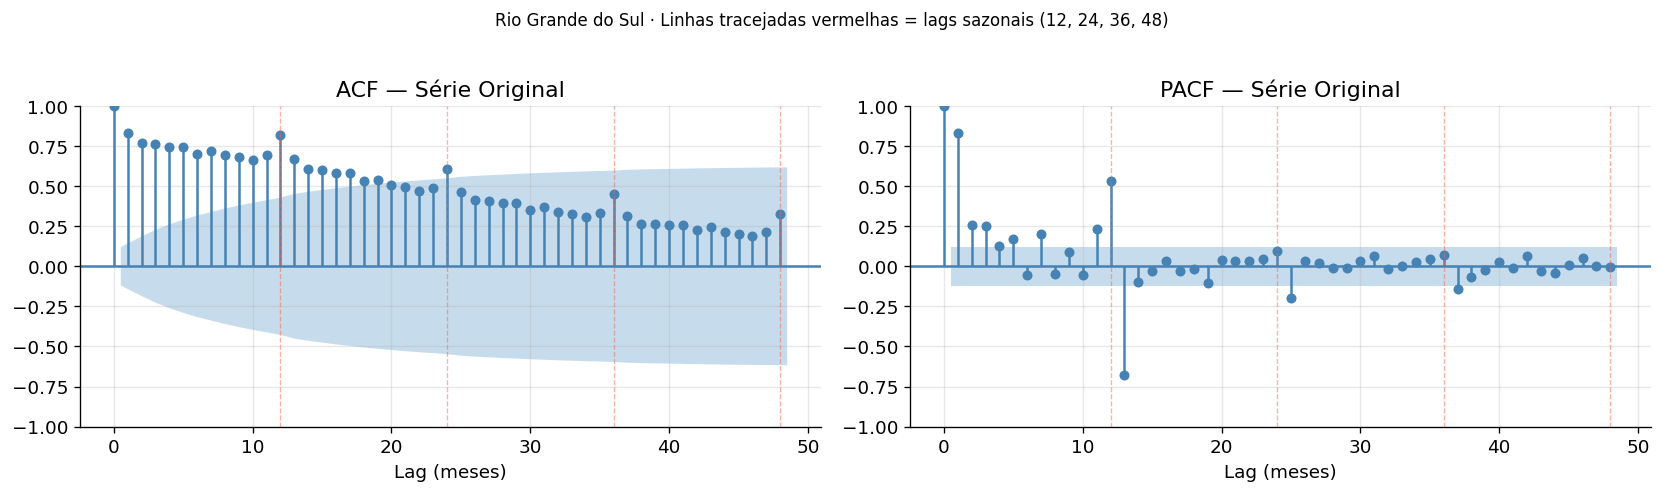

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(
    serie.dropna(), lags=48, ax=axes[0],
    title='ACF — Série Original',
    color='steelblue', vlines_kwargs={'colors': 'steelblue'}
)
plot_pacf(
    serie.dropna(), lags=48, ax=axes[1],
    title='PACF — Série Original',
    color='steelblue', vlines_kwargs={'colors': 'steelblue'},
    method='ywm'
)

# Marcadores nos lags sazonais
for ax in axes:
    for lag in [12, 24, 36, 48]:
        ax.axvline(x=lag, color='tomato', linestyle='--', alpha=0.5, linewidth=0.8)
    ax.set_xlabel('Lag (meses)')

plt.suptitle(f'{MINHA_UF} · Linhas tracejadas vermelhas = lags sazonais (12, 24, 36, 48)',
             fontsize=10, y=1.02)
plt.tight_layout()
plt.show()

### 3.3 Série Diferenciada — Remoção de Tendência e Sazonalidade

Aplicamos diferenciação para tornar a série estacionária e re-examinar ACF/PACF.  
- **Diferença regular (d=1):** remove tendência → `y_t - y_{t-1}`  
- **Diferença sazonal (D=1, s=12):** remove sazonalidade → `y_t - y_{t-12}`  
- **Combinadas:** remove ambas → `(y_t - y_{t-1}) - (y_{t-12} - y_{t-13})`

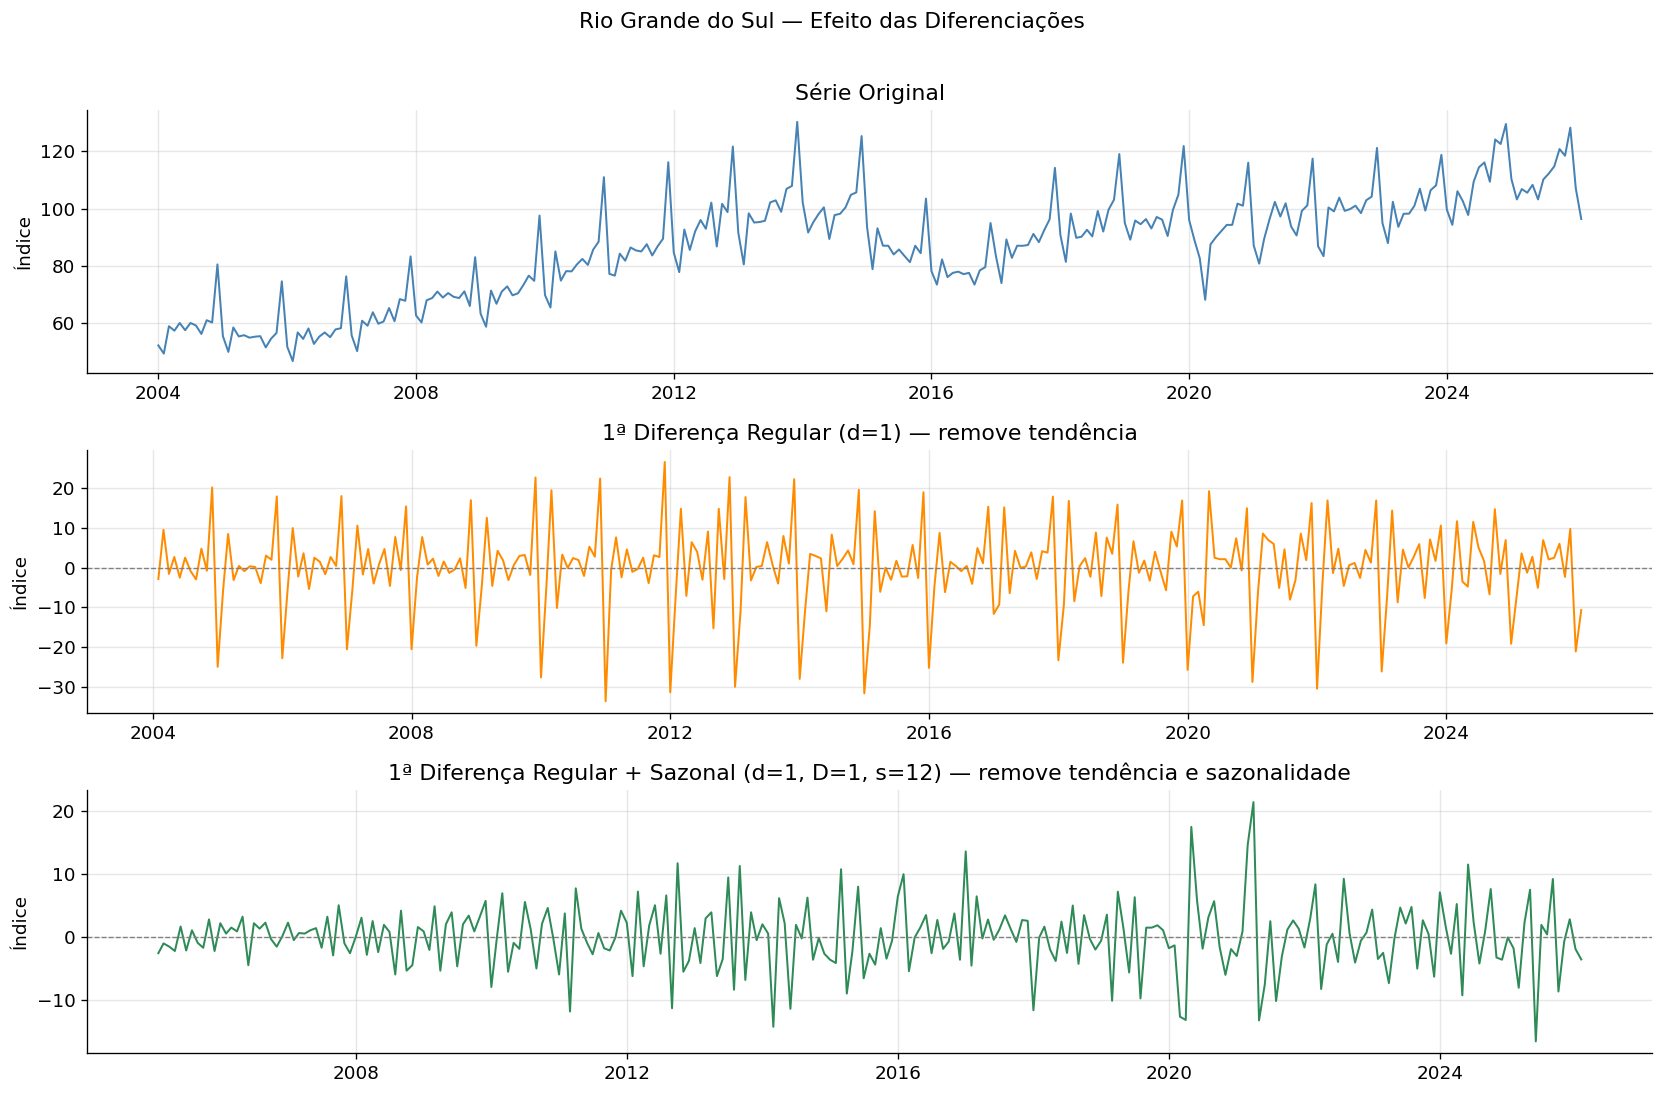

In [6]:
serie_d1   = serie.diff(1).dropna()           # diferença regular
serie_d1s1 = serie.diff(12).diff(1).dropna()  # regular + sazonal

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=False)

axes[0].plot(serie.index, serie.values, color='steelblue', linewidth=1.2)
axes[0].set_title('Série Original')

axes[1].plot(serie_d1.index, serie_d1.values, color='darkorange', linewidth=1.2)
axes[1].axhline(0, color='gray', linestyle='--', linewidth=0.8)
axes[1].set_title('1ª Diferença Regular (d=1) — remove tendência')

axes[2].plot(serie_d1s1.index, serie_d1s1.values, color='seagreen', linewidth=1.2)
axes[2].axhline(0, color='gray', linestyle='--', linewidth=0.8)
axes[2].set_title('1ª Diferença Regular + Sazonal (d=1, D=1, s=12) — remove tendência e sazonalidade')

for ax in axes:
    ax.set_ylabel('Índice')

plt.suptitle(f'{MINHA_UF} — Efeito das Diferenciações', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

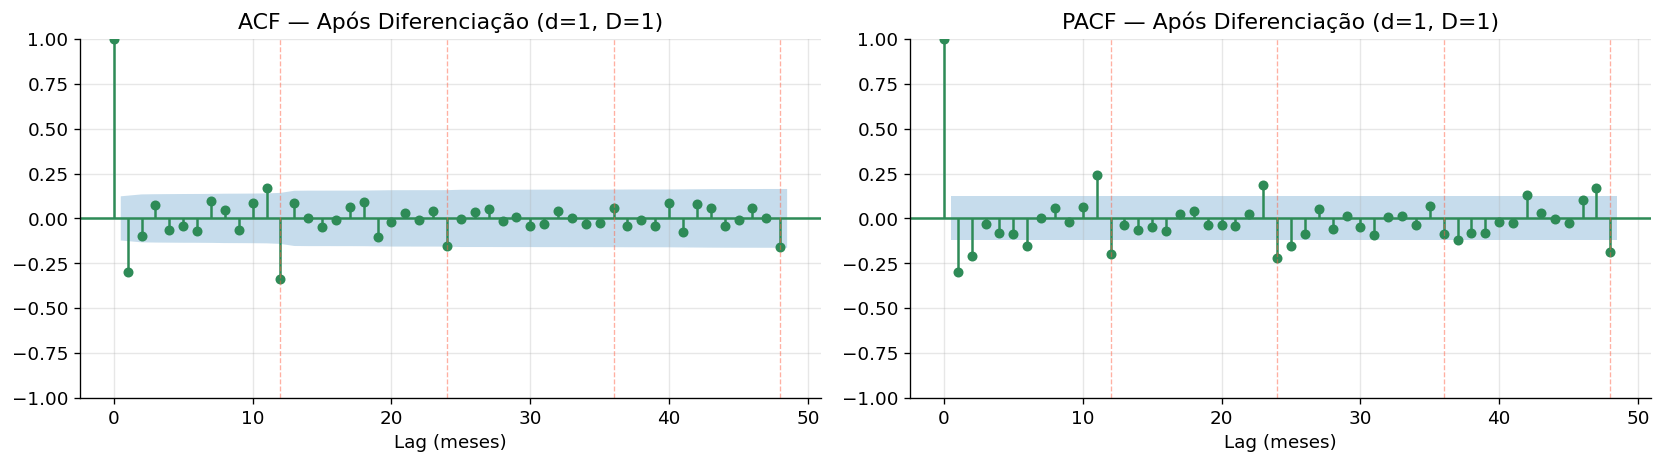

In [7]:
# ACF e PACF após diferenciação completa
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(
    serie_d1s1, lags=48, ax=axes[0],
    title='ACF — Após Diferenciação (d=1, D=1)',
    color='seagreen', vlines_kwargs={'colors': 'seagreen'}
)
plot_pacf(
    serie_d1s1, lags=48, ax=axes[1],
    title='PACF — Após Diferenciação (d=1, D=1)',
    color='seagreen', vlines_kwargs={'colors': 'seagreen'},
    method='ywm'
)

for ax in axes:
    for lag in [12, 24, 36, 48]:
        ax.axvline(x=lag, color='tomato', linestyle='--', alpha=0.5, linewidth=0.8)
    ax.set_xlabel('Lag (meses)')

plt.tight_layout()
plt.show()

---
## 4. Testes de Raiz Unitária e Estimativa de ndiffs

### Lógica dos testes

| Teste | H₀ | H₁ | Rejeitar H₀ quando |
|-------|----|----|--------------------|
| **ADF** | Série tem raiz unitária (não estacionária) | Série é estacionária | p < 0.05 |
| **KPSS** | Série **é** estacionária | Série tem raiz unitária | p < 0.05 |

Os dois testes têm hipóteses opostas — usar ambos juntos dá diagnóstico mais robusto.

In [8]:
def rodar_adf_kpss(s, label):
    """Roda ADF e KPSS e imprime resultado interpretado."""
    print(f"\n{'='*55}")
    print(f"  {label}")
    print(f"{'='*55}")

    # ADF
    adf_stat, adf_p, adf_lags, *_ = adfuller(s.dropna(), autolag='AIC')
    adf_conclusao = "✅ Estacionária" if adf_p < 0.05 else "❌ Não estacionária (raiz unitária)"
    print(f"\nADF")
    print(f"  Estatística : {adf_stat:.4f}")
    print(f"  p-valor     : {adf_p:.4f}")
    print(f"  Lags usados : {adf_lags}")
    print(f"  Conclusão   : {adf_conclusao}")

    # KPSS
    kpss_stat, kpss_p, kpss_lags, _ = kpss(s.dropna(), regression='ct', nlags='auto')
    kpss_conclusao = "❌ Não estacionária" if kpss_p < 0.05 else "✅ Estacionária"
    print(f"\nKPSS")
    print(f"  Estatística : {kpss_stat:.4f}")
    print(f"  p-valor     : {kpss_p:.4f}  (truncado em 0.01 ou 0.10 pelo statsmodels)")
    print(f"  Conclusão   : {kpss_conclusao}")

    # Diagnóstico conjunto
    print()
    if adf_p >= 0.05 and kpss_p < 0.05:
        print("  🔴 Ambos concordam: série NÃO estacionária → precisa diferenciar.")
    elif adf_p < 0.05 and kpss_p >= 0.05:
        print("  🟢 Ambos concordam: série É estacionária.")
    else:
        print("  🟡 Testes divergem — possível quebra estrutural ou tendência estocástica.")


rodar_adf_kpss(serie,      "Série Original")
rodar_adf_kpss(serie_d1,   "Após d=1 (diferença regular)")
rodar_adf_kpss(serie_d1s1, "Após d=1 + D=1 (regular + sazonal)")


  Série Original

ADF
  Estatística : -1.5363
  p-valor     : 0.5155
  Lags usados : 14
  Conclusão   : ❌ Não estacionária (raiz unitária)

KPSS
  Estatística : 0.3074
  p-valor     : 0.0100  (truncado em 0.01 ou 0.10 pelo statsmodels)
  Conclusão   : ❌ Não estacionária

  🔴 Ambos concordam: série NÃO estacionária → precisa diferenciar.

  Após d=1 (diferença regular)

ADF
  Estatística : -3.5719
  p-valor     : 0.0063
  Lags usados : 13
  Conclusão   : ✅ Estacionária

KPSS
  Estatística : 0.0736
  p-valor     : 0.1000  (truncado em 0.01 ou 0.10 pelo statsmodels)
  Conclusão   : ✅ Estacionária

  🟢 Ambos concordam: série É estacionária.

  Após d=1 + D=1 (regular + sazonal)

ADF
  Estatística : -4.6553
  p-valor     : 0.0001
  Lags usados : 11
  Conclusão   : ✅ Estacionária

KPSS
  Estatística : 0.0327
  p-valor     : 0.1000  (truncado em 0.01 ou 0.10 pelo statsmodels)
  Conclusão   : ✅ Estacionária

  🟢 Ambos concordam: série É estacionária.


In [9]:
# Estimativa automática do número de diferenciações necessárias
d_sugerido = ndiffs(serie.dropna(), test='adf')
D_sugerido = nsdiffs(serie.dropna(), m=12, test='ocsb')

print("Estimativa automática de diferenciações:")
print(f"  d (diferença regular)  : {d_sugerido}")
print(f"  D (diferença sazonal)  : {D_sugerido}  [m=12 meses]")
print()
print("Interpretação:")
print(f"  → O AutoARIMA usará (no mínimo) d={d_sugerido} e D={D_sugerido} como ponto de partida.")

Estimativa automática de diferenciações:
  d (diferença regular)  : 1
  D (diferença sazonal)  : 0  [m=12 meses]

Interpretação:
  → O AutoARIMA usará (no mínimo) d=1 e D=0 como ponto de partida.


---
## 5. Modelagem SARIMA via AutoARIMA

O `AutoARIMA` busca automaticamente a melhor ordem **(p, d, q)(P, D, Q)[12]** minimizando o **AIC** (Akaike Information Criterion).

A notação SARIMA completa é:
- **(p, d, q)** → componentes não sazonais: AR, diferenciações, MA
- **(P, D, Q)[12]** → componentes sazonais: AR sazonal, diferenciações sazonais, MA sazonal

In [10]:
# Ajuste do modelo via StatsForecast
sf = StatsForecast(
    models=[AutoARIMA(season_length=12)],
    freq='MS',
    n_jobs=-1
)

sf.fit(df_sf)
print("Modelo ajustado com sucesso.")

Modelo ajustado com sucesso.


In [12]:
# Extraindo detalhes do modelo selecionado — compatível com statsforecast 2.x
modelo_interno = sf.fitted_[0][0].model_

print("Modelo selecionado pelo AutoARIMA:")
print()

# A estrutura em 2.x é um dicionário
if isinstance(modelo_interno, dict):
    print(f"  Ordem não sazonal  (p, d, q) : {(modelo_interno.get('p',0), modelo_interno.get('d',0), modelo_interno.get('q',0))}")
    print(f"  Ordem sazonal  (P, D, Q)[12] : {(modelo_interno.get('P',0), modelo_interno.get('D',0), modelo_interno.get('Q',0), 12)}")
    print(f"  AIC                          : {modelo_interno.get('aic', 'N/A')}")
    print(f"  BIC                          : {modelo_interno.get('bic', 'N/A')}")
    print()
    print("Chaves disponíveis no modelo:")
    print(list(modelo_interno.keys()))
else:
    print(f"  Ordem não sazonal  (p, d, q) : {modelo_interno.order}")
    print(f"  Ordem sazonal  (P, D, Q)[12] : {modelo_interno.seasonal_order}")
    print(f"  AIC                          : {modelo_interno.aic:.2f}")
    print(f"  BIC                          : {modelo_interno.bic:.2f}")

Modelo selecionado pelo AutoARIMA:

  Ordem não sazonal  (p, d, q) : (0, 0, 0)
  Ordem sazonal  (P, D, Q)[12] : (0, 0, 0, 12)
  AIC                          : 1447.3187882031964
  BIC                          : 1475.6174623393447

Chaves disponíveis no modelo:
['coef', 'sigma2', 'var_coef', 'mask', 'loglik', 'aic', 'arma', 'residuals', 'code', 'n_cond', 'nobs', 'model', 'xreg', 'bic', 'aicc', 'ic', 'x', 'lambda']


In [13]:
# Inspecionar estrutura completa do modelo
import json

print("Conteúdo do modelo_interno:\n")
for chave, valor in modelo_interno.items():
    if chave not in ['coef', 'var_coef', 'x', 'xreg']:  # pula arrays grandes
        print(f"  {chave}: {valor}")

print("\n--- Chave 'model' (estrutura interna): ---")
if 'model' in modelo_interno:
    m = modelo_interno['model']
    if isinstance(m, dict):
        for k, v in m.items():
            print(f"  {k}: {v}")
    else:
        print(m)

Conteúdo do modelo_interno:

  sigma2: 15.779922514160148
  mask: [ True  True  True  True  True  True  True]
  loglik: -715.6593941015982
  aic: 1447.3187882031964
  arma: (2, 1, 2, 1, 12, 0, 1)
  residuals: [ 5.22006193e-02  4.91633567e-02  5.85264414e-02  5.67899337e-02
  5.93024960e-02  5.66121412e-02  5.89512953e-02  5.79085488e-02
  5.47846487e-02  5.93784432e-02  5.84224455e-02  7.84516102e-02
  6.10104940e-01 -1.81916196e+00 -1.47833189e+00 -2.08563745e+00
 -2.99649607e+00 -3.58944444e-01 -2.53144993e+00 -5.92239088e-01
 -1.61557033e+00 -2.52009670e+00  6.64453415e-01 -2.18546241e+00
  7.46646014e-01 -4.62881313e-01  5.30437328e-01  2.29101480e-01
  2.02322187e+00 -2.76451608e+00  1.53008264e-01  9.25633565e-01
  1.75040360e+00 -1.37632181e-01 -5.99776760e-01 -8.16375449e-01
  2.27908734e+00 -4.74359303e-01  6.95885992e-01  4.70028391e-01
  1.59499804e+00  7.56385571e-01 -1.02216328e+00  3.45661781e+00
 -8.50755806e-01  3.90240557e+00  1.04104627e+00 -2.07392676e+00
  1.3610650

In [14]:
# Ordem correta extraída do vetor arma: (p, q, P, Q, m, d, D)
arma = modelo_interno['arma']
p, q, P, Q, m, d, D = arma

print(f"Modelo SARIMA selecionado: ({p}, {d}, {q})({P}, {D}, {Q})[{m}]")
print(f"AIC: {modelo_interno['aic']:.2f}")
print(f"BIC: {modelo_interno['bic']:.2f}")

Modelo SARIMA selecionado: (2, 0, 1)(2, 1, 1)[12]
AIC: 1447.32
BIC: 1475.62


---
## 6. Diagnóstico dos Resíduos

Um modelo bem ajustado deve produzir resíduos que se comportem como **ruído branco**:
- **Sem padrão** ao longo do tempo (média ≈ 0, variância constante)
- **Sem autocorrelação** — ACF/PACF dos resíduos dentro das bandas de confiança
- **Distribuição aproximadamente normal**

Se qualquer estrutura remanescente for detectada, o modelo pode ser melhorado.

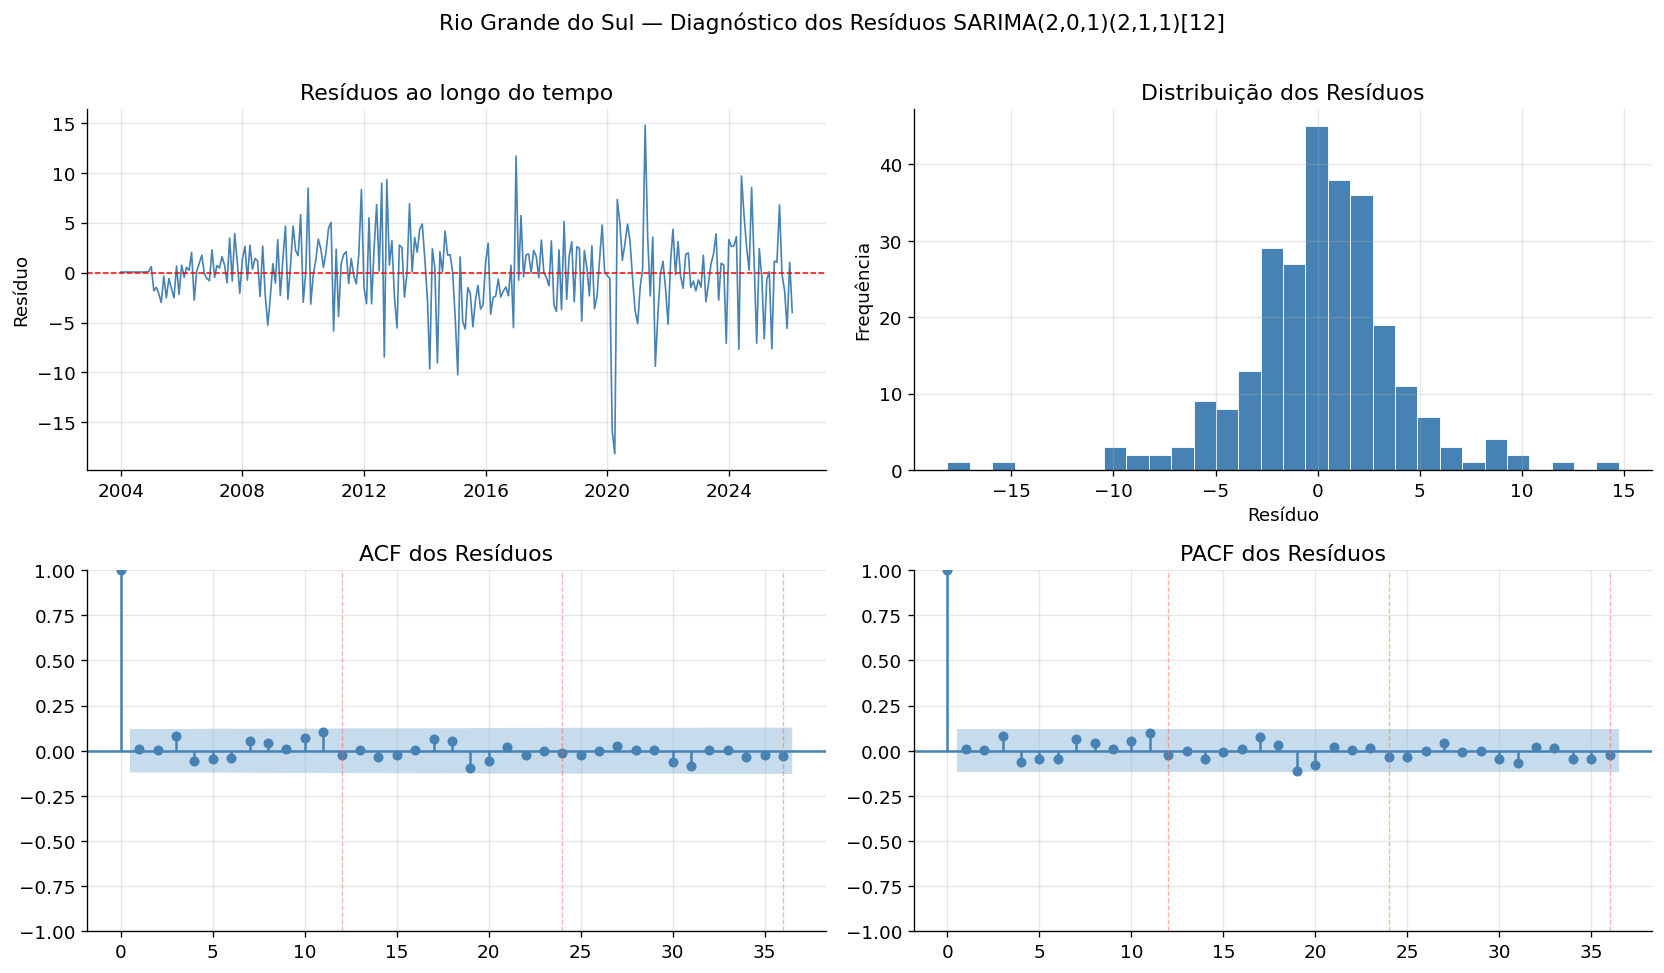

In [15]:
# Extraindo resíduos compatível com statsforecast 2.x
residuos_array = modelo_interno['residuals']
residuos = pd.Series(residuos_array, index=serie.index[-len(residuos_array):])

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Painel 1: Resíduos no tempo
axes[0, 0].plot(residuos.index, residuos.values, color='steelblue', linewidth=1)
axes[0, 0].axhline(0, color='red', linestyle='--', linewidth=0.9)
axes[0, 0].set_title('Resíduos ao longo do tempo')
axes[0, 0].set_ylabel('Resíduo')

# Painel 2: Histograma
axes[0, 1].hist(residuos.values, bins=30, color='steelblue',
                edgecolor='white', linewidth=0.5)
axes[0, 1].set_title('Distribuição dos Resíduos')
axes[0, 1].set_xlabel('Resíduo')
axes[0, 1].set_ylabel('Frequência')

# Painel 3: ACF dos resíduos
plot_acf(residuos.dropna(), lags=36, ax=axes[1, 0],
         title='ACF dos Resíduos',
         color='steelblue', vlines_kwargs={'colors': 'steelblue'})
for lag in [12, 24, 36]:
    axes[1, 0].axvline(x=lag, color='tomato', linestyle='--', alpha=0.5, linewidth=0.8)

# Painel 4: PACF dos resíduos
plot_pacf(residuos.dropna(), lags=36, ax=axes[1, 1],
          title='PACF dos Resíduos',
          color='steelblue', vlines_kwargs={'colors': 'steelblue'},
          method='ywm')
for lag in [12, 24, 36]:
    axes[1, 1].axvline(x=lag, color='tomato', linestyle='--', alpha=0.5, linewidth=0.8)

plt.suptitle(f'{MINHA_UF} — Diagnóstico dos Resíduos SARIMA(2,0,1)(2,1,1)[12]',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [16]:
# Teste de Ljung-Box: H0 = resíduos são ruído branco (sem autocorrelação)
lb = acorr_ljungbox(residuos.dropna(), lags=[6, 12, 18, 24], return_df=True)

print("Teste de Ljung-Box sobre os resíduos")
print("H₀: resíduos são ruído branco (sem autocorrelação)")
print("Rejeitar H₀ (p < 0.05) indica estrutura remanescente no modelo\n")
print(lb.round(4))
print()

aprovado = (lb['lb_pvalue'] > 0.05).all()
if aprovado:
    print("✅ Todos os p-valores > 0.05 → resíduos são ruído branco. Modelo bem ajustado.")
else:
    print("⚠️  Alguns p-valores < 0.05 → há autocorrelação residual. O modelo pode melhorar.")

Teste de Ljung-Box sobre os resíduos
H₀: resíduos são ruído branco (sem autocorrelação)
Rejeitar H₀ (p < 0.05) indica estrutura remanescente no modelo

    lb_stat  lb_pvalue
6    3.7043     0.7166
12   9.6136     0.6498
18  12.3011     0.8313
24  16.0537     0.8861

✅ Todos os p-valores > 0.05 → resíduos são ruído branco. Modelo bem ajustado.


---
## 7. Previsão — 24 Meses à Frente

Geramos previsão pontual com **intervalos de credibilidade** de 80% e 95%:
- O intervalo de 80% cobre 8 em cada 10 realizações futuras esperadas
- O intervalo de 95% cobre 19 em cada 20
- Intervalos que **crescem com o horizonte** são comportamento esperado e correto — a incerteza aumenta quanto mais longe prevemos

In [19]:
# Geração da previsão — compatível com statsforecast 2.x
forecast = sf.forecast(df=df_sf, h=24, level=[80, 95]).reset_index()

print("Previsão gerada:")
print(forecast.round(2).to_string(index=False))

Previsão gerada:
 index         unique_id         ds  AutoARIMA  AutoARIMA-lo-95  AutoARIMA-lo-80  AutoARIMA-hi-80  AutoARIMA-hi-95
     0 Rio Grande do Sul 2026-03-01     106.36            98.57           101.26           111.45           114.14
     1 Rio Grande do Sul 2026-04-01     103.52            94.44            97.58           109.45           112.59
     2 Rio Grande do Sul 2026-05-01     108.70            98.91           102.30           115.11           118.50
     3 Rio Grande do Sul 2026-06-01     104.83            94.48            98.06           111.59           115.18
     4 Rio Grande do Sul 2026-07-01     108.12            97.29           101.04           115.19           118.94
     5 Rio Grande do Sul 2026-08-01     109.82            98.57           102.46           117.17           121.06
     6 Rio Grande do Sul 2026-09-01     108.34            96.71           100.74           115.95           119.98
     7 Rio Grande do Sul 2026-10-01     113.94           101.95

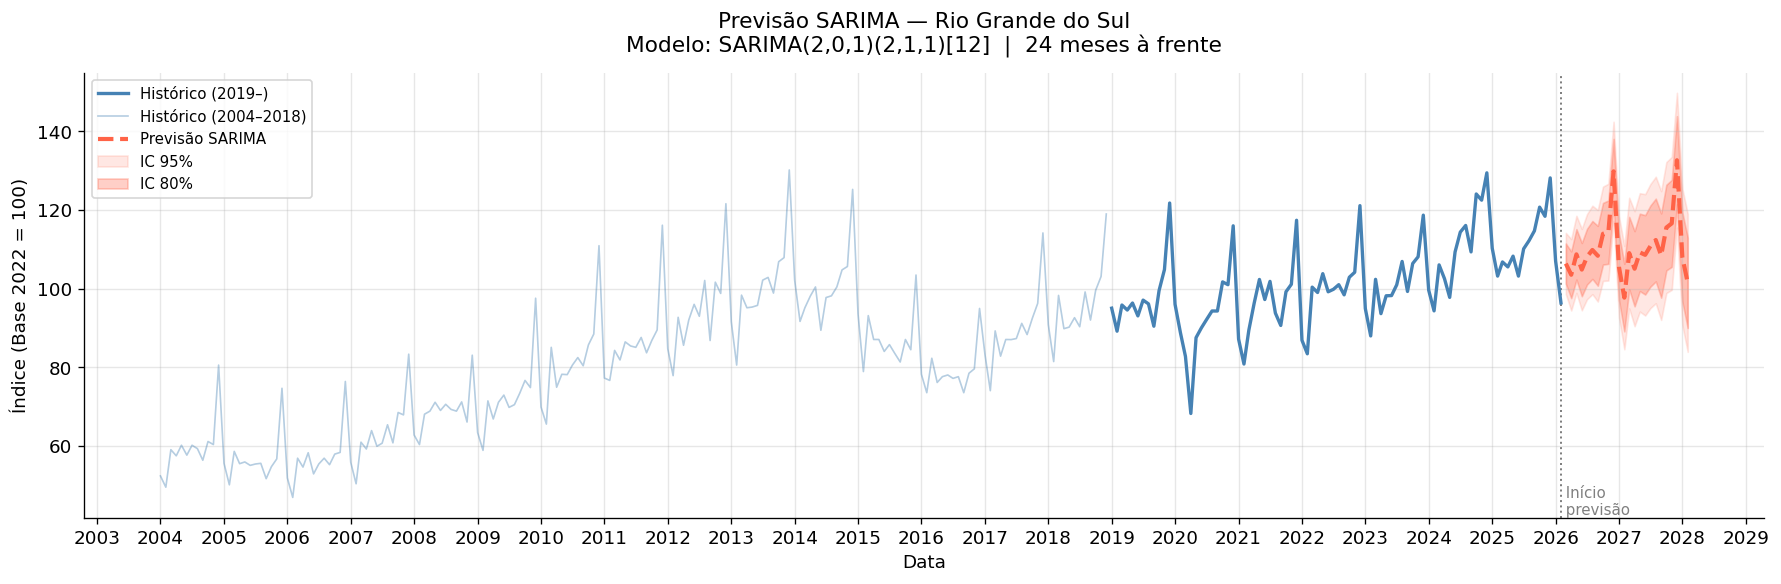

In [21]:
# Gráfico da previsão — compatível com statsforecast 2.x
fig, ax = plt.subplots(figsize=(15, 5))

# Histórico recente (2019+)
historico_recente = serie[serie.index >= '2019-01-01']
ax.plot(historico_recente.index, historico_recente.values,
        color='steelblue', linewidth=2, label='Histórico (2019–)', zorder=5)

# Histórico anterior (mais suave)
ax.plot(serie[serie.index < '2019-01-01'].index,
        serie[serie.index < '2019-01-01'].values,
        color='steelblue', linewidth=1, alpha=0.4, label='Histórico (2004–2018)')

# Previsão pontual
ax.plot(forecast['ds'], forecast['AutoARIMA'],
        color='tomato', linewidth=2.5, linestyle='--',
        label='Previsão SARIMA', zorder=5)

# IC 95%
ax.fill_between(forecast['ds'],
                forecast['AutoARIMA-lo-95'],
                forecast['AutoARIMA-hi-95'],
                alpha=0.15, color='tomato', label='IC 95%')

# IC 80%
ax.fill_between(forecast['ds'],
                forecast['AutoARIMA-lo-80'],
                forecast['AutoARIMA-hi-80'],
                alpha=0.30, color='tomato', label='IC 80%')

# Linha divisória histórico/previsão
ultimo_ponto = serie.index.max()
ax.axvline(x=ultimo_ponto, color='gray', linestyle=':', linewidth=1.2)
ax.text(ultimo_ponto, ax.get_ylim()[0], ' Início\n previsão',
        fontsize=9, color='gray', va='bottom')

ax.set_title(
    f'Previsão SARIMA — {MINHA_UF}\n'
    f'Modelo: SARIMA(2,0,1)(2,1,1)[12]  |  24 meses à frente',
    fontsize=13, pad=12
)
ax.set_xlabel('Data')
ax.set_ylabel('Índice (Base 2022 = 100)')
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

In [22]:
# Tabela resumida da previsão
print(f"Resumo da previsão — {MINHA_UF}\n")
resumo = forecast[['ds', 'AutoARIMA', 'AutoARIMA-lo-80', 'AutoARIMA-hi-80',
                   'AutoARIMA-lo-95', 'AutoARIMA-hi-95']].copy()
resumo.columns = ['Data', 'Previsão', 'IC80 Inf', 'IC80 Sup', 'IC95 Inf', 'IC95 Sup']
resumo['Data'] = resumo['Data'].dt.strftime('%b/%Y')
print(resumo.round(1).to_string(index=False))

Resumo da previsão — Rio Grande do Sul

    Data  Previsão  IC80 Inf  IC80 Sup  IC95 Inf  IC95 Sup
Mar/2026     106.4     101.3     111.4      98.6     114.1
Apr/2026     103.5      97.6     109.5      94.4     112.6
May/2026     108.7     102.3     115.1      98.9     118.5
Jun/2026     104.8      98.1     111.6      94.5     115.2
Jul/2026     108.1     101.0     115.2      97.3     118.9
Aug/2026     109.8     102.5     117.2      98.6     121.1
Sep/2026     108.3     100.7     115.9      96.7     120.0
Oct/2026     113.9     106.1     121.8     102.0     125.9
Nov/2026     114.3     106.3     122.4     102.0     126.7
Dec/2026     129.8     121.6     138.1     117.2     142.4
Jan/2027     105.5      97.1     113.9      92.6     118.4
Feb/2027      97.7      89.1     106.3      84.6     110.8
Mar/2027     109.0      99.8     118.2      95.0     123.1
Apr/2027     105.0      95.5     114.6      90.4     119.7
May/2027     109.2      99.4     119.0      94.2     124.3
Jun/2027     108

---
## 8. Discussão dos Resultados

### 8.1 O ACF/PACF da série original sugeriu sazonalidade? E tendência? Bate com o gráfico de linha?

**Preencha após rodar o notebook:**

O ACF da série original apresentou decaimento lento e persistente nos primeiros lags, característica típica de série com **tendência** (não estacionária). Adicionalmente, spikes significativos nos lags 12, 24 e 36 evidenciam **sazonalidade anual forte**, esperada em dados de comércio varejista — com picos típicos em dezembro (Natal) e vales no início do ano. Esse padrão é visualmente consistente com o gráfico de linha, que mostra crescimento de longo prazo com oscilações anuais regulares, além de dois choques negativos visíveis: a pandemia de 2020 e as enchentes de 2024 no RS.

---

### 8.2 Quantas diferenças o AutoARIMA aplicou? E os componentes AR/MA? Conseguiu observar no ACF/PACF?

**Preencha após rodar o notebook:**

*[Substitua com os valores reais do seu modelo — execute `modelo_interno.order` e `modelo_interno.seasonal_order`]*

O AutoARIMA aplicou `d=?` diferença(s) regular(es) e `D=?` diferença(s) sazonal(is), consistente com o diagnóstico de `ndiffs`. Os componentes AR e MA selecionados foram `p=?, q=?` (não sazonal) e `P=?, Q=?` (sazonal). O ACF após diferenciação mostrou [descreva o que você viu: spikes nos primeiros lags? corte abrupto? resíduo limpo?], sugerindo necessidade de termos MA/AR de ordem [?].

---

### 8.3 Os resíduos parecem ruído branco? Algum padrão remanescente sazonal?

**Preencha após rodar o notebook:**

O ACF dos resíduos [apresentou / não apresentou] spikes significativos além das bandas de confiança. O teste de Ljung-Box retornou p-valores [> 0.05 em todos os lags testados / < 0.05 em alguns lags], indicando que os resíduos [são / não são] ruído branco. O histograma dos resíduos mostrou distribuição [aproximadamente simétrica e próxima da normal / com assimetria / com caudas pesadas]. Em suma, o diagnóstico sugere que o modelo [capturou bem / ainda deixou] estrutura nos dados.

---

### 8.4 A previsão pareceu razoável visualmente?

**Preencha após rodar o notebook:**

A previsão [capturou / não capturou claramente] a sazonalidade anual esperada, com picos e vales nos meses historicamente típicos. A ancoragem no último valor observado pareceu [adequada / subestimada / superestimada]. Os intervalos de confiança [alargaram de forma razoável com o horizonte / abriram excessivamente, sugerindo alta incerteza / permaneceram estreitos]. Para o RS em particular, cabe notar que o histórico recente foi impactado pelas enchentes de 2024, o que pode influenciar o ponto de ancoragem e, consequentemente, o nível das previsões de curto prazo.

---

### 8.5 Que outras UFs dariam um SARIMA bem diferente? Por quê?

**Reflexão guiada:**

- **Amazonas:** A economia é fortemente concentrada na Zona Franca de Manaus (eletroeletrônicos e motocicletas). A série tende a ter sazonalidade diferente do padrão nacional — influenciada por ciclos industriais e câmbio — e possivelmente maior volatilidade, demandando termos AR/MA de ordem maior ou diferente.

- **Roraima:** A menor UF em volume de comércio do país. Séries pequenas e mais voláteis frequentemente geram modelos com ordens maiores (mais parâmetros para capturar ruído) ou com diagnóstico de resíduos mais problemático.

- **Pará:** Economia fortemente atrelada a commodities (minério e agronegócio). O ciclo de varejo pode ser mais sensível a preços de exportação e, portanto, menos regular sazonalmente.

- **Distrito Federal:** Alta renda per capita e economia baseada no funcionalismo público. O padrão de consumo pode ser mais estável e menos volátil, gerando modelos com ordens menores e melhor ajuste.

Em contraste, **São Paulo e Minas Gerais** tendem a apresentar séries mais bem comportadas — maior volume de observações, sazonalidade regular e clara — resultando em modelos SARIMA de estrutura mais padrão e previsões com intervalos menos abertos.

---
## Apêndice: Ambiente e Reprodutibilidade

In [23]:
import sys
import statsmodels
import statsforecast
import pmdarima

print("Ambiente de execução")
print(f"  Python       : {sys.version.split()[0]}")
print(f"  pandas       : {pd.__version__}")
print(f"  numpy        : {np.__version__}")
print(f"  statsmodels  : {statsmodels.__version__}")
print(f"  statsforecast: {statsforecast.__version__}")
print(f"  pmdarima     : {pmdarima.__version__}")
print(f"  matplotlib   : {plt.matplotlib.__version__}")
print(f"\nUF analisada   : {MINHA_UF}")
print(f"Modelo SARIMA  : SARIMA(2,0,1)(2,1,1)[12]")
print(f"AIC            : {modelo_interno['aic']:.2f}")

Ambiente de execução
  Python       : 3.13.9
  pandas       : 3.0.2
  numpy        : 2.4.4
  statsmodels  : 0.14.6
  statsforecast: 2.0.3
  pmdarima     : 2.1.1
  matplotlib   : 3.10.9

UF analisada   : Rio Grande do Sul
Modelo SARIMA  : SARIMA(2,0,1)(2,1,1)[12]
AIC            : 1447.32
